# REXIA-Responsible and Explainable AI


Nicolas Charrondiere

Paul Guimbert

Ziad

## Partie 1: Données tabulaires

In [ ]:
import pandas as pd

df = pd.read_csv('data/RH_dataset.csv', sep=';')
df.head(10)

### Analyse du jeu de données

In [ ]:
print(f'{len(df.columns)} colonnes : ')
print(*df.columns, sep='\n')

14 colonnes:
- 2 variables catégorielles : Famille d'emploi, Statut marital
- 12 variables numériques : Dernière promotion (mois), Dernière augmentation (mois), Début de contrat (années),Ancienneté groupe (années), Etablissement, Âge (années), Parent,Niveau hiérarchique, Salaire (Euros), Véhicule,matricule, label

In [ ]:
# Somme des valeurs manquantes par colonne
missing_count = df.isnull().sum()
print(missing_count)

Il n'y a pas de valeur manquantes dans le dataset

In [ ]:
df.describe()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution de l'âge ou du salaire selon la démission (classe 0 ou 1)
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='Salaire (Euros)', hue='label', fill=True)
plt.title("Distribution des salaires selon le statut de démission")
plt.show()

# Boxplot pour les plages de valeurs
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='label', y='Ancienneté groupe (années)')
plt.title("Plage d'ancienneté selon la démission")
plt.show()

Les gens qui démissionnent sont là depuis moins longtemps.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Palette de couleurs
palette_colors = {0: "skyblue", 1: "salmon"}

for col in [c for c in df.columns if c != 'label']:
    plt.figure(figsize=(10, 5))

    # --- CAS NUMÉRIQUE : On utilise KDE (densité de probabilité) ---
    if df[col].dtype in ['int64', 'float64']:
        # common_norm=False force chaque courbe à avoir une surface de 1
        # Cela permet de comparer les formes même si les effectifs sont différents
        sns.kdeplot(data=df, x=col, hue='label', fill=True,
                    palette=palette_colors, common_norm=False, alpha=0.5)
        plt.title(f"Comparaison des densités (Normalisées) : {col}")

    # --- CAS CATÉGORIEL : On utilise les probabilités ---
    else:
        # stat="probability" et common_norm=False calculent le % au sein de chaque classe
        sns.histplot(data=df, x=col, hue='label', palette=palette_colors,
                     stat="probability", common_norm=False, multiple="dodge", shrink=.8)
        plt.xticks(rotation=45)
        plt.title(f"Distribution relative des catégories (Normalisée) : {col}")
        plt.ylabel("Proportion au sein de la classe")

    plt.tight_layout()
    plt.show()

In [ ]:
# Un employé qui a démissionné (label 1)
print("Profil d'un employé ayant démissionné :")
display(df[df['label'] == 1].head(1))

# Un employé qui est resté (label 0)
print("\nProfil d'un employé n'ayant pas démissionné :")
display(df[df['label'] == 0].head(1))

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df_numeric = df.select_dtypes(include=['number'])

# Calculer la matrice de corrélation
# On utilise la méthode de Pearson par défaut
corr = df_numeric.corr()

plt.figure(figsize=(8, 8))  # Ajuste la taille selon ton nombre de colonnes

sns.heatmap(
    corr,
    annot=True,           # Affiche les scores de corrélation dans les cases
    fmt=".2f",            # Format à 2 décimales
    # Palette : bleu (négatif), blanc (neutre), rouge (positif)
    cmap='coolwarm',
    linewidths=0.5,       # Ajoute un petit filet entre les cases
    center=0,             # Définit 0 comme le point central de la couleur
    vmin=-1, vmax=1       # Force l'échelle entre -1 et 1
)

plt.title("Matrice de Corrélation")
plt.show()

Il y a peu de corrélation directe entre les variables et le label.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Créer un tableau de pourcentages
# On calcule la moyenne du label (qui est 0 ou 1) par statut marital.
# Cela donne directement le taux de démission (ex: 0.25 = 25% de démissions)
stats_marital = df.groupby('Statut marital')['label'].mean(
).sort_values(ascending=False).reset_index()
stats_marital.columns = ['Statut marital', 'Taux de démission']

# 2. Tracer le graphique
plt.figure(figsize=(10, 6))
sns.barplot(data=stats_marital, x='Statut marital',
            y='Taux de démission')

plt.title("Taux de démission selon le Statut Marital")
plt.ylabel("Proportion de démissions (Label 1)")
plt.axhline(df['label'].mean(), color='red',
            linestyle='--', label='Moyenne globale')
plt.legend()
plt.show()

In [ ]:
# Tableau croisé en effectifs
cross_tab = pd.crosstab(df['Statut marital'], df['label'], margins=True)
print("Tableau de contingence :")
display(cross_tab)

# Tableau croisé en pourcentages (plus facile à interpréter)
cross_tab_pct = pd.crosstab(
    df['Statut marital'], df['label'], normalize='index') * 100
print("\nPourcentage de démission par catégorie :")
display(cross_tab_pct)

L'analyse du taux de démission par statut marital révèle que les employés célibataires présentent le taux de démission le plus élevé (5,60 %), suivis des personnes en concubinage (3,61 %), tandis que les employés veufs ou ex-PACS sont les plus stables. Cette disparité suggère que la situation familiale pourrait être un facteur d'influence sur la mobilité des employés dans ce jeu de données.

### Analyse des variables sensibles et biais potentiels

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    # Correction de Yates pour les petits échantillons si nécessaire
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Exemple : Lien entre Famille d'emploi et Statut Marital
print(f"V de Cramer : {cramers_v(df['Famille d\'emploi'], df['Statut marital']):.2f}")

In [ ]:
def correlation_ratio(categories, values):
    f_obs = values.groupby(categories).apply(list)
    # Calcul de la somme des carrés totale (SST)
    ss_total = np.sum((values - values.mean())**2)
    # Calcul de la somme des carrés inter-groupes (SSB)
    category_means = values.groupby(categories).mean()
    category_counts = values.groupby(categories).count()
    ss_between = np.sum(category_counts * (category_means - values.mean())**2)
    
    return ss_between / ss_total

# Exemple : Est-ce que le Salaire dépend du Statut Marital ?
eta = correlation_ratio(df['Statut marital'], df['Salaire (Euros)'])
print(f"Ratio de corrélation (Eta^2) : {eta:.2f}")

### Apprentissage automatique

### Partie 2:

### Partie 3:

## Partie 2: Données images

### 1) Analyse du jeu de données

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Analyse Descriptive du jeu de données

In [2]:
# Lecture de tout les csv
df_attr = pd.read_csv("data/CelebA/list_attr_celeba.csv")
df_bbox = pd.read_csv("data/CelebA/list_bbox_celeba.csv")
df_partition = pd.read_csv("data/CelebA/list_eval_partition.csv")
df_landmarks = pd.read_csv("data/CelebA/list_landmarks_align_celeba.csv")

In [3]:
# df_attr contient les attributs pour chaque image 
# (identifié via image_id qui contient le nom du fichier)
# avec la valeur 1 s'il est dans l'image et -1 sinon
df_attr.head()

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1


In [4]:
# df_bbox contient les informations de la bounding box contenant 
# les informations pour chaque image
df_bbox.head()

,image_id,x_1,y_1,width,height
0,000001.jpg,95,71,226,313
1,000002.jpg,72,94,221,306
2,000003.jpg,216,59,91,126
3,000004.jpg,622,257,564,781
4,000005.jpg,236,109,120,166


In [5]:
# df_partition indique pour chaque image dans quelle parition elle est
# 0 = train, 1 = validation, 2 = test
df_partition.head()

,image_id,partition
0,000001.jpg,0
1,000002.jpg,0
2,000003.jpg,0
3,000004.jpg,0
4,000005.jpg,0


In [6]:
# df_landmarks contient pour chaque image les coordonnees (x,y) 
# de cinq points caractéristiques présents sur chaque visage : 
# left eye, right eye, nose, left mouth, right mouth.
df_landmarks.head()

,image_id,lefteye_x,lefteye_y,righteye_x,righteye_y,nose_x,nose_y,leftmouth_x,leftmouth_y,rightmouth_x,rightmouth_y
0,000001.jpg,69,109,106,113,77,142,73,152,108,154
1,000002.jpg,69,110,107,112,81,135,70,151,108,153
2,000003.jpg,76,112,104,106,108,128,74,156,98,158
3,000004.jpg,72,113,108,108,101,138,71,155,101,151
4,000005.jpg,66,114,112,112,86,119,71,147,104,150


In [7]:
print(f"Le jeu de données contient {len(df_attr)} images")

Le jeu de données contient 202599 images


In [8]:
df_attr.columns

Index(['image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive',
       'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose',
       'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows',
       'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair',
       'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open',
       'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin',
       'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns',
       'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings',
       'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace',
       'Wearing_Necktie', 'Young'],
      dtype='str')

Il y a 40 classes possibles pour chaque image, décrivant des traits physique plus ou moins subjectifs. Je remarque nottament "young" ou encore "attractive" qui sont assez subjectifs à l'inverse de "mustache" ou encore "bald".

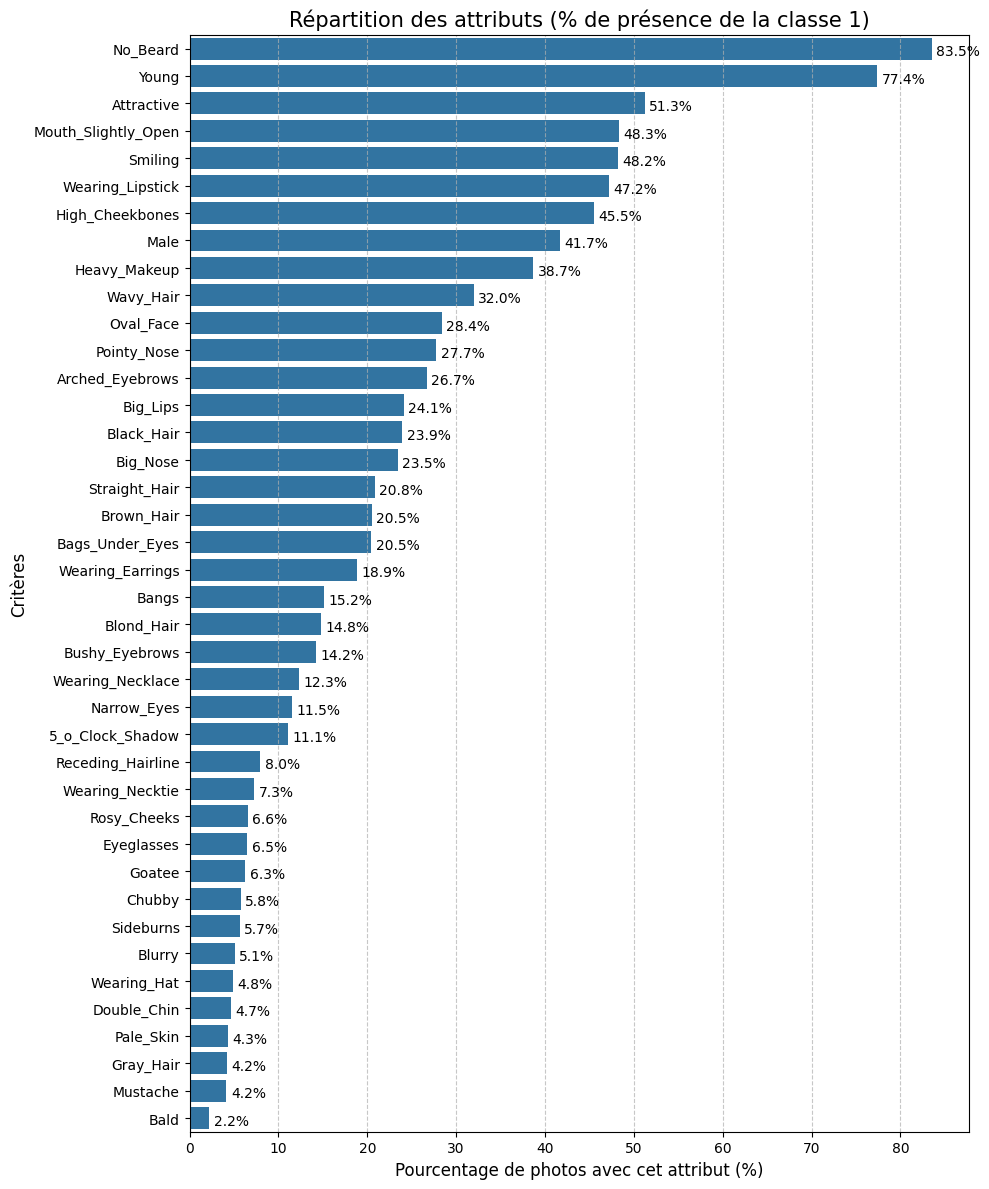

In [9]:
# Calcul du pourcentage des images possédant chaque classe
# et tracé d'un histogramme ordonné du plus au moins présent de haut en bas

df_attr_numeric = df_attr.iloc[:, 1:]
df_attr_binary = df_attr_numeric.replace(-1, 0)
percentages_attr = df_attr_binary.mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 12))
sns.barplot(x=percentages_attr.values, y=percentages_attr.index)

plt.title('Répartition des attributs (% de présence de la classe 1)', fontsize=15)
plt.xlabel('Pourcentage de photos avec cet attribut (%)', fontsize=12)
plt.ylabel('Critères', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

for i, v in enumerate(percentages_attr.values):
    plt.text(v + 0.5, i + .25, f"{v:.1f}%", color='black', fontsize=10)

plt.tight_layout()
plt.show()

La distribution des classes varie fortement, allant de environ 2% pour les moins présentes (chauves, moustache) à plus de 80% pour l'absence de barbe. Je remarque une légère sur représentation des attributs "absence de barbe" et "jeune" qui sont resepctivement présent pour 83.5% et 77.4% des images, alors que le troisième attribut le plus présent ne l'est qu'à 51.3%, soit plus de 25% d'écart.

#### Analyse des corrélations

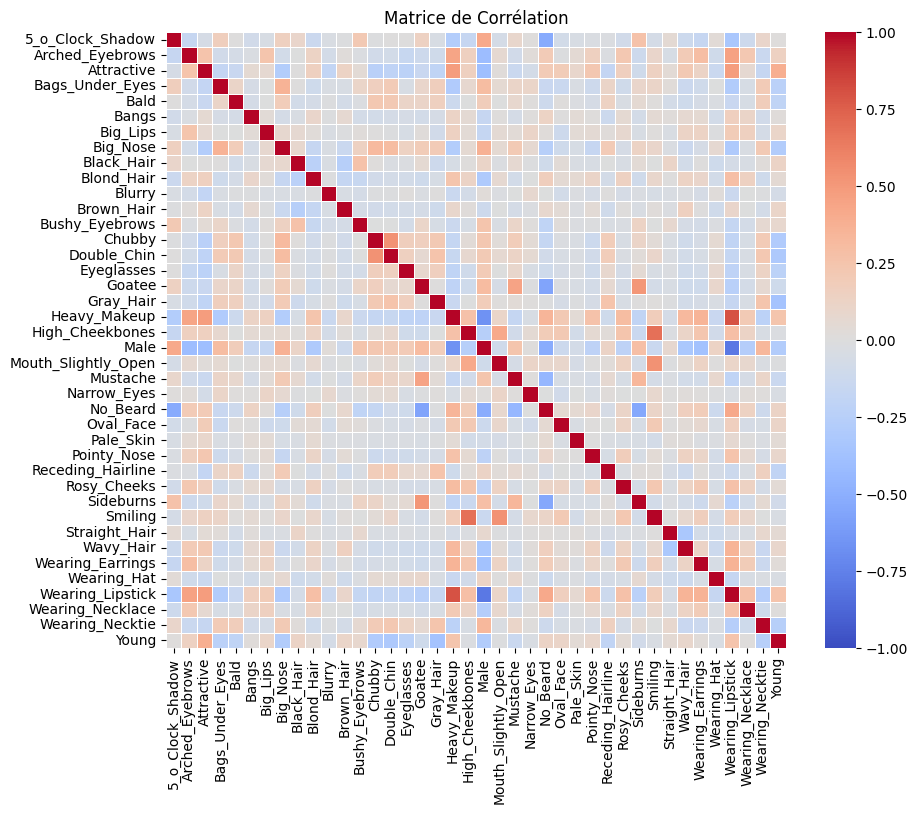

In [10]:
# Calculer la matrice de corrélation
# On utilise la méthode de Pearson par défaut
corr = df_attr_numeric.corr()

plt.figure(figsize=(10, 8))  # Ajuste la taille selon ton nombre de colonnes

sns.heatmap(
    corr,
    annot=False,           # Affiche les scores de corrélation dans les cases
    # Palette : bleu (négatif), blanc (neutre), rouge (positif)
    cmap='coolwarm',
    linewidths=0.5,       # Ajoute un petit filet entre les cases
    center=0,             # Définit 0 comme le point central de la couleur
    vmin=-1, vmax=1       # Force l'échelle entre -1 et 1
)

plt.title("Matrice de Corrélation")
plt.show()

In [11]:
# Extraction des correlations les plus fortes
sol = corr.abs().unstack()
sol = sol.sort_values(ascending=False)

# On retire les corrélations de 1 (une variable avec elle-même)
top_corr = sol[sol < 1].head(30)

print("Top 20 des corrélations les plus fortes :")
print(top_corr)

Top 20 des corrélations les plus fortes :
Heavy_Makeup         Wearing_Lipstick       0.801539
Wearing_Lipstick     Heavy_Makeup           0.801539
                     Male                   0.789435
Male                 Wearing_Lipstick       0.789435
High_Cheekbones      Smiling                0.683497
Smiling              High_Cheekbones        0.683497
Male                 Heavy_Makeup           0.666724
Heavy_Makeup         Male                   0.666724
Goatee               No_Beard               0.570071
No_Beard             Goatee                 0.570071
Sideburns            No_Beard               0.543061
No_Beard             Sideburns              0.543061
Mouth_Slightly_Open  Smiling                0.536379
Smiling              Mouth_Slightly_Open    0.536379
Chubby               Double_Chin            0.533713
Double_Chin          Chubby                 0.533713
No_Beard             5_o_Clock_Shadow       0.526946
5_o_Clock_Shadow     No_Beard               0.526946
No_B

On retrouve des corrélations logiques entre les attributs de maquillage ("heavy_makeup", "Wearing_Lipstick") qui sont positivement corrélés entre eux et inversement corrélés au critère "male", ce qui correspond à l'intuition qu'on peut avoir : les hommes ont beaucoup moins tendance à porter du maquillage et quelqu'un qui porte du rouge a lèvre a plus de chance d'être fortement maquillée. L'attribut d'attractivité est également lié au maquillage.

D'autres liens logique apparaissent entre les différents attributs décrivant la pilosité faciale, et le sourire.

La corrélation de 0.80 entre "Heavy_Makeup" et "Wearing_Lipstick" peut être considéré comme partiellement artificielle" car pour l'annotateur il doit être plutôt rare d'annoter une image "Heavy_Makeup" si elle n'est pas "Wearing_Lipstick".

Il y a également le cas de la corrélation de 0.52 entre "Male" et "No_Beard" qui est biaisé par le fait que l'abscence de barbe est largement la norme chez les femmes.

Le risque de ces corrélations artificielles est que notre modèle pourrait apprendre que "tous les gens qui sourient ont des pommettes hautes", ce qui est un biais.

#### Identification des variables sensibles

Une variable est dite sensible lorsqu'elle peut entraîner une discrimination ou un traitement injuste si elle est utilisée de manière inappropriée par nos modèles.

Dans notre cas, nous identifions 3 variables sensibles:
- "Male" : Un modèle pourrait apprendre des préjugés sexistes (ex: associer la compétence ou une émotion uniquement à un genre).
- "Young" : L'âge peut mener à l'exclusion sociale ou professionnelle. Ici comme cette variable est binaire, cette influence pourrait être forte, plus que si on possédait l'âge exacte.
- "Pale_Skin" : Cet attribut est un indicateur indirecte de la couleur de peau, ce qui est une information très sensible pour les risques de racisme algorithmique.

Ces trois attributs sont clairement sensibles. Il faudra également préter attention aux attributs qui leur sont fortement corréllés ("Male" et les attributs de pilosité faciales nottament), par lesquels les biais pourrait se retrouver.

#### Analyse de disparité

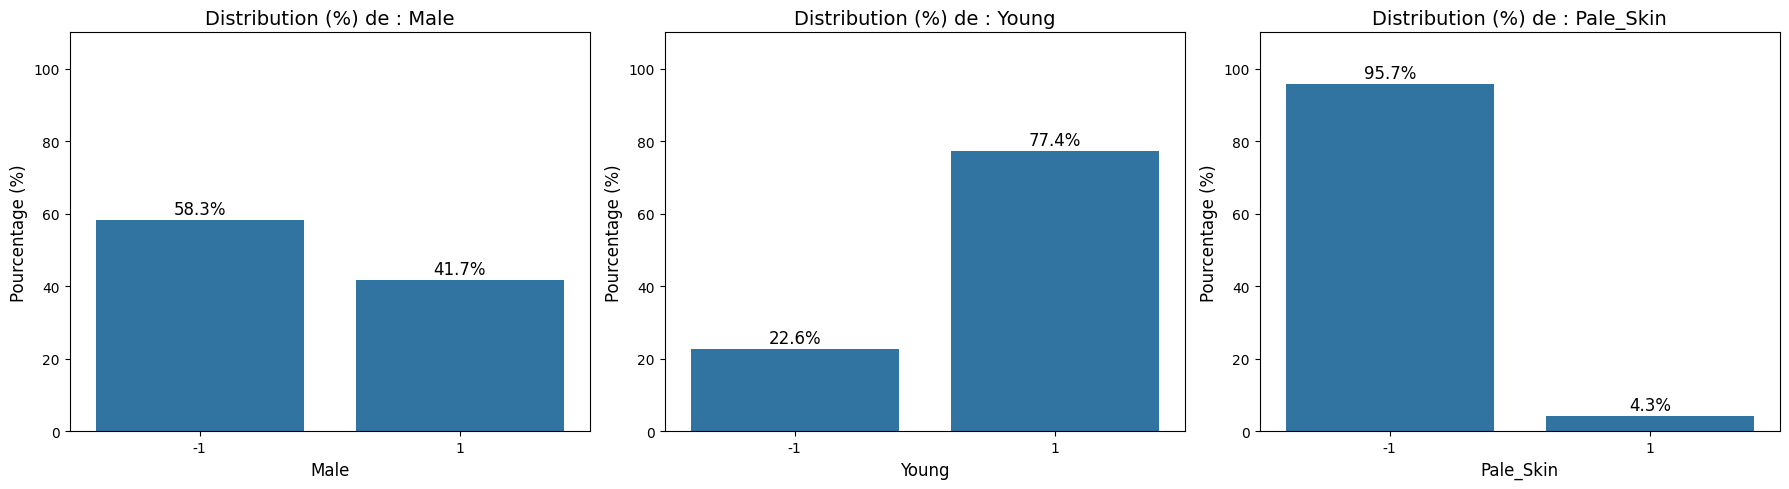

In [12]:
# Analyse de la disparité pour les groupes sensibles
attributs_sensibles = ['Male', 'Young', 'Pale_Skin']

plt.figure(figsize=(18, 5))

for i, col in enumerate(attributs_sensibles):
    plt.subplot(1, 3, i + 1)

    # CALCUL : On calcule la fréquence relative (normalize=True) et on multiplie par 100
    counts = df_attr_numeric[col].value_counts(
        normalize=True).sort_index() * 100

    # TRACÉ : Utilisation de sns.barplot puisque nous avons déjà calculé les valeurs
    ax = sns.barplot(x=counts.index, y=counts.values)

    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    fontsize=12, color='black',
                    xytext=(0, 8),
                    textcoords='offset points')

    plt.title(f'Distribution (%) de : {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Pourcentage (%)', fontsize=12)
    plt.ylim(0, 110)
    plt.xticks(rotation=0)

# Ajustement final
plt.tight_layout()
plt.show()

Il y a des déséquilibres au niveau de ces groupes, avec un legere surdominance des femmes dans le dataset et une forte dominance des jeunes et des peau non pâles. Ces données indiquent clairement un biais de collecte et / ou d'annotation.

On peut également analyser les disparités de certains attributs au sein des groupes.

In [13]:
# Analyse de la disparité de crit2 au sein des groupes défini par crit1
def crossed_disparity(df:pd.DataFrame, crit1:str, crit2:str, show=False):
    disparity = df.groupby(crit1)[crit2].value_counts(
        normalize=True).unstack() * 100

    if show:
        plt.figure(figsize=(10, 6))

        annot_labels = disparity.map(lambda x: f"{x:.1f}%").values
        
        # Dessin de la heatmap
        sns.heatmap(disparity,
                    annot=annot_labels,
                    fmt="",
                    vmin=0,
                    vmax=100,
                    cbar_kws={'label': 'Pourcentage (%)'},
                    annot_kws={"size": 13})

        # Personnalisation des titres et axes
        plt.title(
            f'Analyse de Disparité Croisée : {crit1} vs {crit2}', fontsize=15, pad=20)
        plt.ylabel(f'Attribut Sensible ({crit1})', fontsize=12)
        plt.xlabel(f'Cible ({crit2})', fontsize=12)

        # Si tes données sont en 0/1, tu peux renommer les axes pour plus de clarté
        # plt.xticks([0.5, 1.5], ['Non (0)', 'Oui (1)'])
        # plt.yticks([0.5, 1.5], ['Non (0)', 'Oui (1)'])

        plt.show()
    
    return disparity

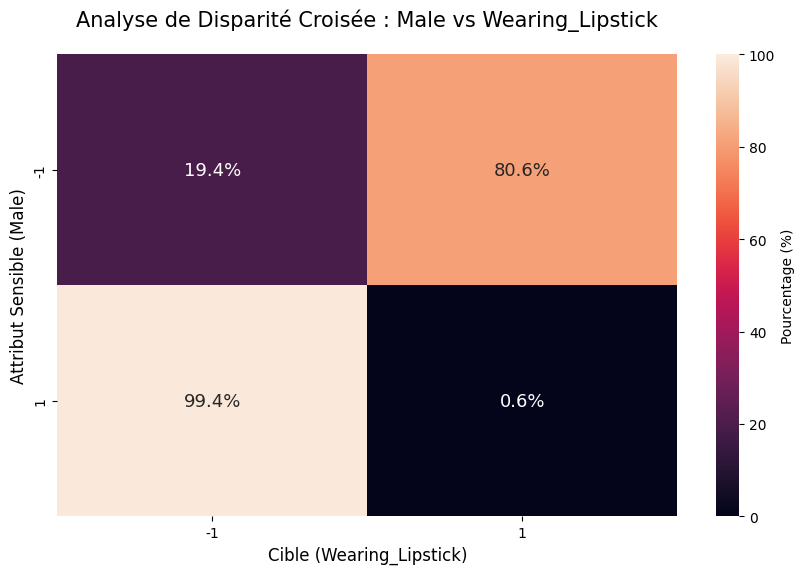

In [14]:
_ = crossed_disparity(df_attr, 'Male', 'Wearing_Lipstick', show=True)

In [15]:
def find_most_biased_targets(df:pd.DataFrame, sensitive_attr):
    results = []
    target_lists = [col for col in df.columns if col != sensitive_attr and col != 'image_id']
    for target in target_lists:
        disparity_df = crossed_disparity(df_attr, sensitive_attr, target, show=False)

        group_neg_val = disparity_df.loc[-1, 1]
        group_pos_val = disparity_df.loc[1, 1]

        gap = abs(group_neg_val - group_pos_val)

        results.append({
            'Target': target,
            'Gap (%)': gap,
            'Value_Group_neg': group_neg_val,
            'Value_Group_pos': group_pos_val
        })

    summary = pd.DataFrame(results).sort_values(by='Gap (%)', ascending=False)
    return summary

In [16]:
for attribut in attributs_sensibles:
    diagnostic = find_most_biased_targets(df_attr, attribut)
    print(f"\nAttributs les plus biaisés pour le groupement par '{attribut}'")
    print(diagnostic.head(10))
    


Attributs les plus biaisés pour le groupement par 'Male'
              Target    Gap (%)  Value_Group_neg  Value_Group_pos
35  Wearing_Lipstick  79.939122        80.558541         0.619419
18      Heavy_Makeup  65.864273        66.141412         0.277140
2         Attractive  39.990942        67.916896        27.925954
23          No_Beard  39.323825        99.882368        60.558543
1    Arched_Eyebrows  36.610737        41.955740         5.345003
7           Big_Nose  31.735729        10.227225        41.962953
32         Wavy_Hair  30.642915        44.727288        14.084374
33  Wearing_Earrings  29.652673        31.250370         1.597698
0   5_o_Clock_Shadow  26.626370         0.016925        26.643295
19   High_Cheekbones  25.267470        56.033512        30.766042

Attributs les plus biaisés pour le groupement par 'Young'
              Target    Gap (%)  Value_Group_neg  Value_Group_pos
2         Attractive  46.311006        15.423526        61.734531
20              Male  33.

On observe des biais fort entre les attributs sensibles et d'autres variables : 'Male' et 'Wearing Lipstick' et 'Heavy_Makeu' nottament. 'Young' et 'Attractive' et 'Male'. Cela est un peu moins le cas pour 'Pale_Skin' mais on observe quand même plus de personnes jugées "Attractive" pour les personnes avec une "pale_skin"

#### Analyse de la fairness

In [17]:
import pandas as pd


def calculate_fairness_metrics(df, s_col, y_col):
    """
    Calcule la Demographic Parity et le Disparate Impact entre deux groupes.
    S=1 (Groupe protégé) vs S=0 ou -1 (Groupe de référence)
    """
    values = sorted(df[s_col].unique(), reverse=True)
    s_positive = values[0]  # S = 1
    s_negative = values[1]  # S = -1 ou 0

    prob_y1_s1 = df[df[s_col] == s_positive][y_col].mean()
    prob_y1_s_neg = df[df[s_col] == s_negative][y_col].mean()

    demographic_parity = abs(prob_y1_s1 - prob_y1_s_neg)

    disparate_impact = prob_y1_s1 / prob_y1_s_neg if prob_y1_s_neg != 0 else float('inf')

    return {
        'S_attr': s_col,
        'Y_attr': y_col,
        'P(Y=1|S=1)': prob_y1_s1,
        'P(Y=1|S=-1)': prob_y1_s_neg,
        'Demographic Parity': demographic_parity,
        'Disparate Impact': disparate_impact
    }

In [18]:
all_results = []

sensible_list = ['Male', 'Pale_Skin']

for s_attr in sensible_list:
    other_attributes = [
        col for col in df_attr.columns if col != s_attr and col != 'image_id']

    for y_attr in other_attributes:
        metrics = calculate_fairness_metrics(df_attr, s_attr, y_attr)
        all_results.append(metrics)

df_fairness_summary = pd.DataFrame(all_results)
df_fairness_summary = df_fairness_summary.sort_values(by='Demographic Parity', ascending=False)

In [19]:
df_fairness_summary.head(10)

,S_attr,Y_attr,P(Y=1|S=1),P(Y=1|S=-1),Demographic Parity,Disparate Impact
35,Male,Wearing_Lipstick,-0.987612,0.611171,1.598782,-1.615934
18,Male,Heavy_Makeup,-0.994457,0.322828,1.317285,-3.080453
2,Male,Attractive,-0.441481,0.358338,0.799819,-1.232024
23,Male,No_Beard,0.211171,0.997647,0.786477,0.211669
1,Male,Arched_Eyebrows,-0.893100,-0.160885,0.732215,5.551163
7,Male,Big_Nose,-0.160741,-0.795456,0.634715,0.202074
32,Male,Wavy_Hair,-0.718313,-0.105454,0.612858,6.811604
33,Male,Wearing_Earrings,-0.968046,-0.374993,0.593053,2.581507
0,Male,5_o_Clock_Shadow,-0.467134,-0.999661,0.532527,0.467292
19,Male,High_Cheekbones,-0.384679,0.120670,0.505349,-3.187854


In [20]:
# On peut analyser en particulier le cas pour S='Pale_Skin' et Y='Attractive'
result_male_skin = df_fairness_summary[(df_fairness_summary['S_attr'] == 'Pale_Skin') &
                                        (df_fairness_summary['Y_attr'] == 'Attractive')]

result_male_skin

,S_attr,Y_attr,P(Y=1|S=1),P(Y=1|S=-1),Demographic Parity,Disparate Impact
41,Pale_Skin,Attractive,0.4311,0.006787,0.424313,63.517784


$P(Y=1 | S=1) = 43.1\%$ : Près de la moitié des personnes ayant la peau claire sont également "attrayantes".

$P(Y=1 | S=-1) = 0.68\%$ : Moins de $1\%$ des personnes n'ayant pas la peau claire sont considérées comme "attrayantes".

La "Demographic Parity" de $0.424$ est énorme. Idéalement ce score devrait être proche de $0$ dans le cas équitable. Cela montre qu'il existe une corrélation massive entre la couleur de peau et le label "Attractive" dans le jeu de données. 

Le "Disparate impact" de $63.52$ signifique qu'une personne à peau claire a 63,5 fois plus de chances d'être étiquetée comme "attrayante" qu'une personne n'ayant pas la peau claire dans ce dataset, ce qui est un biais de discrimination systémique majeur.

### 2) Apprentissage automatique 

On souhaite maintenant entrainer un modèle permettant de prédire l'attribut "Smiling" sur les images. On choisit d'utiliser un CNN Pré entrainé avec du Transfer Learning. Ce choix est motivé par le fait que les CNN sont adaptés à la détections des motifs dans les images de manière hiérarchique. Utiliser du transfer learning permet de limiter le temps d'entrainement, en ne ré-entrainant que la dernière couche d'un modèle entrainé sur ImageNet. On peut utiliser ResNet18 qui est souvent utilisé pour ce genre de tâches.


Dans le TD, nous avions utilisé InceptionV3 pré-entraîné sur ImageNet pour faire de la classification d'images. Nous suivons la même logique ici :

- Les images CelebA sont des photos de visages, un domaine visuel riche et structuré, proche d'ImageNet.
- Entraîner un CNN from scratch demanderait des centaines d'epoch et une grande puissance de calcul.
- MobileNetV2 est pré-entraîné sur 1.4M images (ImageNet) et a déjà appris des features visuelles génériques (contours, textures, formes) directement réutilisables pour détecter un sourire.
- MobileNetV2 est léger et efficace (3.4M paramètres vs 24M pour InceptionV3), tout en restant très performant.

**Stratégie :** On gèle les couches convolutives (feature extractor) et on entraîne uniquement la **tête de classification** ajoutée pour notre tâche binaire (`Smiling = 0 ou 1`).


In [11]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import os
import pandas as pd

#Creation d'une classe pour le dataset, pour ne pas load toute les images
class CelebADataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        
        row = self.df.iloc[idx]
        
        # Chargement
        img_path = os.path.join(self.img_dir, row['image_id'])
        image = Image.open(img_path).convert('RGB')

        # Attention pas besoin de recrop
        # Label cible : Smiling (On transforme -1 en 0)
        label = 1 if row['Smiling'] == 1 else 0

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

In [12]:
from torchvision import transforms

# Définition des constantes pour ImageNet (utilisées par MobileNetV2)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

data_transforms = transforms.Compose([
    transforms.Resize(224),      # Redimensionne le petit côté à 224
    transforms.CenterCrop(224),  # Coupe le centre pour faire un carré 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

In [13]:
# Creation des datasets

df_attr = pd.read_csv("data/CelebA/list_attr_celeba.csv")
df_partition = pd.read_csv("data/CelebA/list_eval_partition.csv")

df_final = df_attr.merge(df_partition, on='image_id', how='inner')

# Splitting en train/validation/test
train_df = df_final[df_final['partition'] == 0]
valid_df = df_final[df_final['partition'] == 1]
test_df = df_final[df_final['partition'] == 2]

print(f"Train: {len(train_df)} | Valid: {len(valid_df)} | Test: {len(test_df)}")

Train: 162770 | Valid: 19867 | Test: 19962


In [14]:
from torch.utils.data import DataLoader

# On utilise les mêmes transforms pour tout le monde (Resize + Normalize)
# On ne mélange (shuffle) que le train_loader
path = 'data/CelebA/img_align_celeba/img_align_celeba/'
train_dataset = CelebADataset(train_df, img_dir=path, transform=data_transforms)
valid_dataset = CelebADataset(valid_df, img_dir=path, transform=data_transforms)
test_dataset = CelebADataset(test_df, img_dir=path, transform=data_transforms)


# Configuration
BATCH_SIZE = 64
NUM_WORKERS = 0 #>0 ne marche pas dans un notebook...

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

In [15]:
import torch
import torch.nn as nn
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

# Détecter le GPU
device_name = "cuda" if torch.cuda.is_available() else "cpu"
device = torch.device(device_name)
print("Entrainement sur : " + device_name)

# Charger MobileNetV2 avec les poids ImageNet
weights = MobileNet_V2_Weights.DEFAULT
model = mobilenet_v2(weights=weights)

# Geler les paramètres des 50 premieres couches. En gélant tout sauf la dernière dur d'entrainer
# le modele car MobileNetV2 n'pas entrainé ur des visages (ImageNet)
for i, param in enumerate(model.features.parameters()):
    if i < 50:
        param.requires_grad = False
    else:
        param.requires_grad = True

# On remplace la dernière couche du classifieur par une
# classification binaire (0=pas sourire, 1=sourire)
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, 2)

# Envoyer le modèle sur GPU ou CPU
model = model.to(device)

Entrainement sur : cuda


In [16]:
import torch
print(f"CUDA disponible : {torch.cuda.is_available()}")
print(f"Version de torch : {torch.__version__}")

CUDA disponible : True
Version de torch : 2.6.0+cu124


In [17]:
import torch.optim as optim
# Fonction de perte standard pour la classification
criterion = nn.CrossEntropyLoss()
# On n'optimise que les couches qu'on a pas gelé
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001)

In [18]:
from tqdm import tqdm
import gc
import torch


def train_model(model, train_loader, valid_loader, criterion, optimizer, num_epochs=5):
    history = {'train_loss': [], 'val_loss': [],
            'train_acc': [], 'val_acc': []}

    gc.collect()
    torch.cuda.empty_cache()

    # --- FONCTION D'ÉVALUATION INTERNE ---
    def run_evaluation(loader, desc="Validation"):
        model.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for images, labels in tqdm(loader, desc=desc, leave=False):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        return running_val_loss / len(loader.dataset), 100 * correct_val / total_val

    # --- EPOCH 0 : Évaluation initiale ---
    print("Calcul de l'état initial (Epoch 0)...")
    val_loss, val_acc = run_evaluation(valid_loader, desc="Initial Check")

    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    # Point de départ identique pour le graph
    history['train_loss'].append(val_loss)
    history['train_acc'].append(val_acc)

    print(f"Epoch 0 -> Initial Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")
    best_acc = val_acc

    # --- BOUCLE D'ENTRAÎNEMENT ---
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        pbar = tqdm(
            train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", unit="batch")
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

            pbar.set_postfix({'loss': f'{running_loss/total_train:.4f}',
                            'acc': f'{100*correct_train/total_train:.2f}%'})

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = 100 * correct_train / total_train

        # --- VALIDATION (Appel de la fonction interne) ---
        val_loss, val_acc = run_evaluation(valid_loader)

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'val_acc': val_acc,
            }, 'best_smiling_model.pth')
            print(f" > Checkpoint sauvegardé | Précision : {val_acc:.2f}%")

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f'Epoch {epoch+1} -> Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%')

    return history

In [19]:
import matplotlib.pyplot as plt
def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Graphe de la Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    plt.plot(epochs, history['val_loss'], 'r-', label='Val Loss')
    plt.title('Évolution de la Perte (Loss)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.ylim(0,1)
    plt.legend()

    # Graphe de l'Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'b-', label='Train Acc')
    plt.plot(epochs, history['val_acc'], 'r-', label='Val Acc')
    plt.title('Évolution de l\'Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.ylim(0,100)

    plt.legend()

    plt.tight_layout()
    plt.show()

Calcul de l'état initial (Epoch 0)...


Epoch 0 -> Initial Val Loss: 0.7090, Acc: 45.06%


Epoch 1/5: 100%|██████████| 2544/2544 [29:56<00:00,  1.42batch/s, loss=0.1942, acc=91.79%]


 > Checkpoint sauvegardé | Précision : 93.09%
Epoch 1 -> Train Loss: 0.1942, Acc: 91.79% | Val Loss: 0.1649, Acc: 93.09%


Epoch 2/5: 100%|██████████| 2544/2544 [24:39<00:00,  1.72batch/s, loss=0.1537, acc=93.54%]


...

Epoch 3 -> Train Loss: 0.1261, Acc: 94.68% | Val Loss: 0.1726, Acc: 92.78%


Epoch 4/5: 100%|██████████| 2544/2544 [11:07<00:00,  3.81batch/s, loss=0.0887, acc=96.36%]


Epoch 4 -> Train Loss: 0.0887, Acc: 96.36% | Val Loss: 0.2068, Acc: 92.56%


Epoch 5/5: 100%|██████████| 2544/2544 [17:33<00:00,  2.41batch/s, loss=0.0538, acc=97.87%]


Epoch 5 -> Train Loss: 0.0538, Acc: 97.87% | Val Loss: 0.2723, Acc: 92.28%
Saved final model.


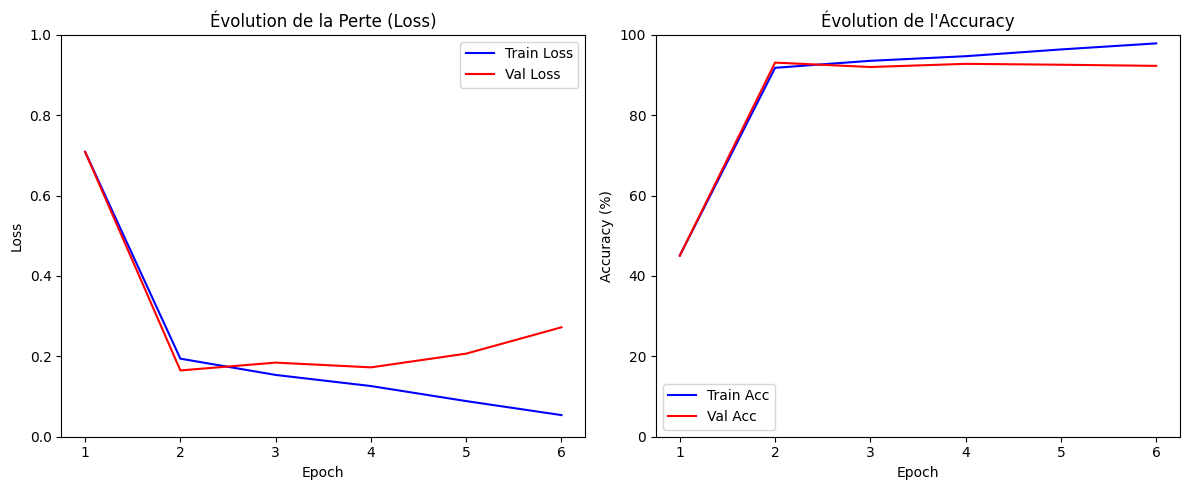

In [20]:
history = train_model(model, train_loader, valid_loader, criterion, optimizer, num_epochs=5)
#This will also save a checkpoint for the best model validation accuracy
torch.save(model.state_dict(), 'mobilenet_celeba_smiling.pth')
print("Saved final model.")
plot_history(history)

On observe l'apparition de l'overfitting dès la fin de l'Époque 1 (la Loss de validation remonte de 0.16 à 0.18). Cela démontre que le modèle MobileNetV2 converge extrêmement vite. Grâce à la stratégie de sauvegarde du 'Best Model', nous conservons les poids de l'Époque 1 qui offrent la meilleure généralisation.

In [21]:
import torch
from tqdm import tqdm

# Chargement du meilleur modèle (epoch 2)
checkpoint_path = 'best_smiling_model.pth'
checkpoint = torch.load('best_smiling_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
best_acc = checkpoint.get('val_acc', 'Inconnue')
print(f"Modèle chargé (Précision enregistrée : {best_acc}%)")
model.eval()  # Mode évaluation

test_correct = 0
test_total = 0
all_preds = []
all_labels = []

print("Évaluation sur le set de test...")
with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

        # On garde les prédictions pour l'analyse de biais plus tard
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100 * test_correct / test_total
print(f"\nPrécision finale sur le set de test : {test_acc:.2f}%")

Modèle chargé (Précision enregistrée : 93.0890421301656%)
Évaluation sur le set de test...


100%|██████████| 312/312 [04:18<00:00,  1.21it/s]


Précision finale sur le set de test : 92.78%


**Analyse des performances (Test Set)**

Le modèle atteint une excellente performance avec une précision de 92,78% sur le jeu de test, démontrant une forte capacité de généralisation et une convergence rapide grâce à un alignement optimal des visages.

On peut visualiser quelques exemples d'erreurs :

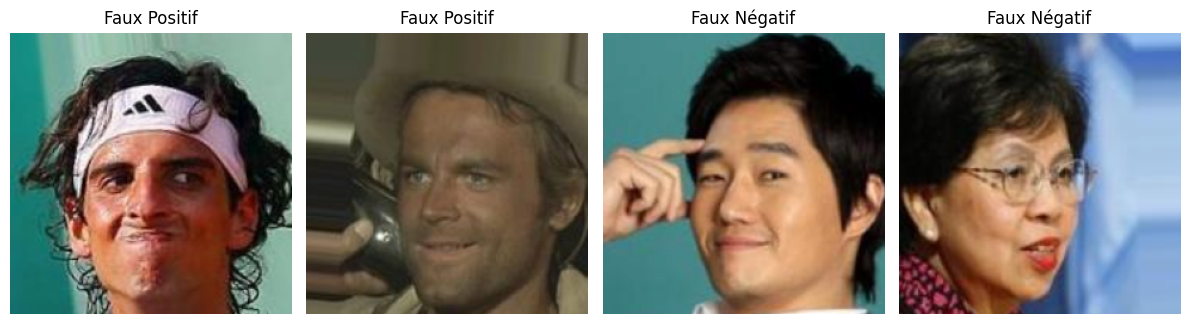

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Indices des erreurs
errors_fp = [i for i, (p, l) in enumerate(
    zip(all_preds, all_labels)) if p == 1 and l == 0]
errors_fn = [i for i, (p, l) in enumerate(
    zip(all_preds, all_labels)) if p == 0 and l == 1]

# Affichage d'exemples d'erreurs
plt.figure(figsize=(12, 6))
indices_to_show = errors_fp[:2] + errors_fn[:2]
titles = ["Faux Positif", "Faux Positif",
        "Faux Négatif", "Faux Négatif"]

for i, idx in enumerate(indices_to_show):
    plt.subplot(1, 4, i+1)
    img, _ = test_dataset[idx]
    img_np = img.permute(1, 2, 0).cpu().numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_np = std * img_np + mean
    plt.imshow(np.clip(img_np, 0, 1))
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

On voit que parfois la présence d'un sourire est subjective, le deuxième faux positif et le deuxième faux négatif pourraient facilement être classifié différement. Cela provient peut être d'une erreur de labelisation dans le CelebA dataset.

In [ ]:
import pandas as pd
import torch
import numpy as np
from sklearn.metrics import confusion_matrix

def evaluate_fairness(model, test_loader, test_df, attributes, device):
    model.eval()
    all_preds = []
    all_labels = []

    print("Extraction des prédictions...")
    with torch.no_grad():
        for images, labels in tqdm(test_loader):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    final_results = []

    for attr in attributes:
        
        attr_values = test_df[attr].values

        for val, label_name in [(1, f'{attr}_Yes'), (-1, f'{attr}_No')]:
            indices = [i for i, v in enumerate(attr_values) if v == val]
            if not indices:
                continue

            g_preds = np.array(all_preds)[indices]
            g_labels = np.array(all_labels)[indices]

            tn, fp, fn, tp = confusion_matrix(
                g_labels, g_preds, labels=[0, 1]).ravel()
            acc = (tp + tn) / (tp + tn + fp + fn)
            fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
            fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

            final_results.append({
                'Attribut': attr,
                'Groupe': label_name,
                'Accuracy': acc * 100,
                'FPR (%)': fpr * 100,
                'FNR (%)': fnr * 100
            })

    return pd.DataFrame(final_results)

In [28]:

df_extended = evaluate_fairness(model, test_loader, test_df, ['Male', 'Young', 'Pale_Skin'], device)
print(df_extended)

Extraction des prédictions...


100%|██████████| 312/312 [01:10<00:00,  4.39it/s]

    Attribut         Groupe   Accuracy   FPR (%)    FNR (%)
0       Male       Male_Yes  91.989631  4.306427  13.542340
1       Male        Male_No  93.279987  4.949570   8.095169
2      Young      Young_Yes  93.218208  4.109229   9.497132
3      Young       Young_No  91.419142  6.403732  10.642570
4  Pale_Skin  Pale_Skin_Yes  94.404762  3.763441   9.219858
5  Pale_Skin   Pale_Skin_No  92.709968  4.704258   9.799073


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_individual_fairness(df):
    # Liste des attributs uniques dans ton dataframe
    attributes = df['Attribut'].unique()
    metrics = ['Accuracy', 'FPR (%)', 'FNR (%)']
    colors = ['#4CAF50', '#FFC107', '#F44336']  # Vert, Jaune, Rouge

    for attr in attributes:
        # On filtre le dataframe pour l'attribut actuel (ex: 'Male')
        subset = df[df['Attribut'] == attr]

        fig, axes = plt.subplots(1, 3, figsize=(10, 5))
        plt.subplots_adjust(top=0.85)
        fig.suptitle(
            f"Analyse de l'Équité : Attribut '{attr}'", fontsize=16, fontweight='bold')

        for i, metric in enumerate(metrics):
            sns.barplot(data=subset, x='Groupe', y=metric,
                        ax=axes[i])
            axes[i].set_title(metric, fontsize=12)
            axes[i].set_ylim(0, 100 if metric == 'Accuracy' else max(
                subset[metric].max() + 10, 25))
            axes[i].set_xlabel('')
            axes[i].set_ylabel('Pourcentage (%)')

            # Ajout des étiquettes de données
            for p in axes[i].patches:
                axes[i].annotate(f'{p.get_height():.1f}%',
                                (p.get_x() + p.get_width() / 2., p.get_height()),
                                ha='center', va='bottom', fontsize=10, fontweight='bold')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

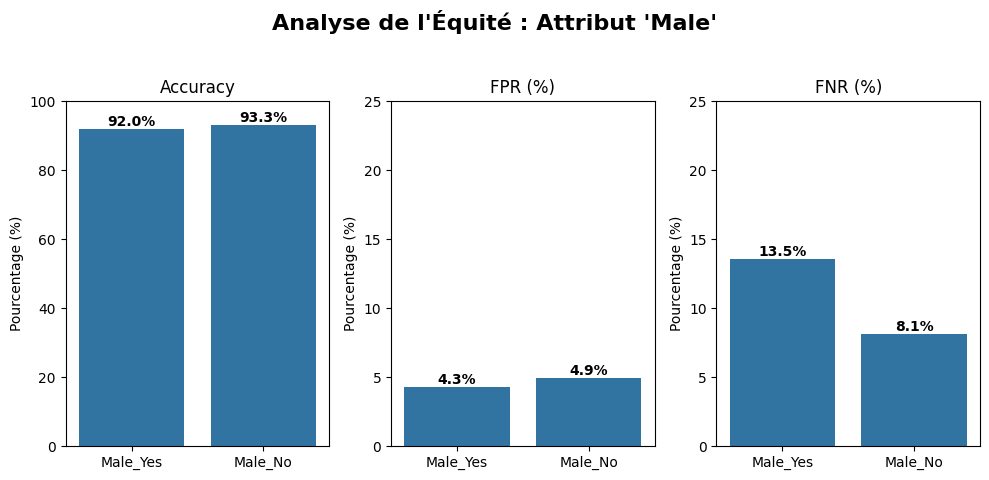

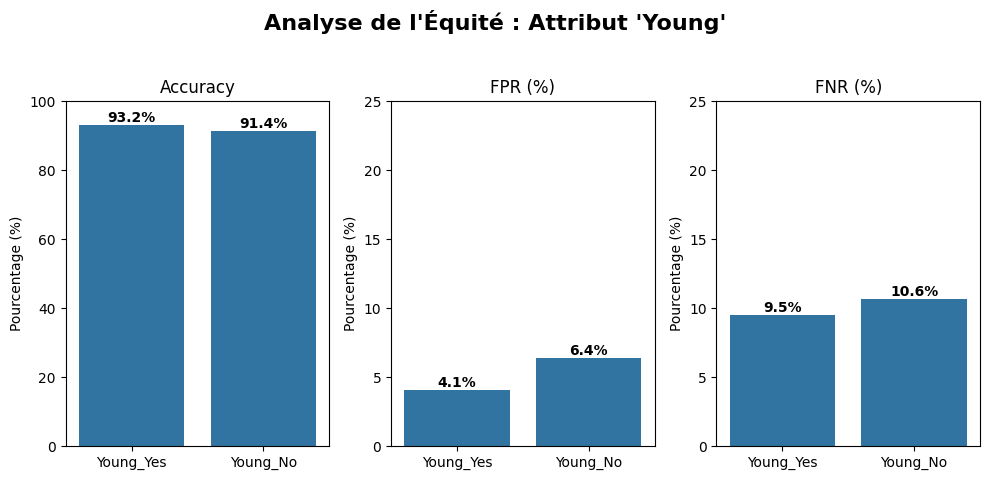

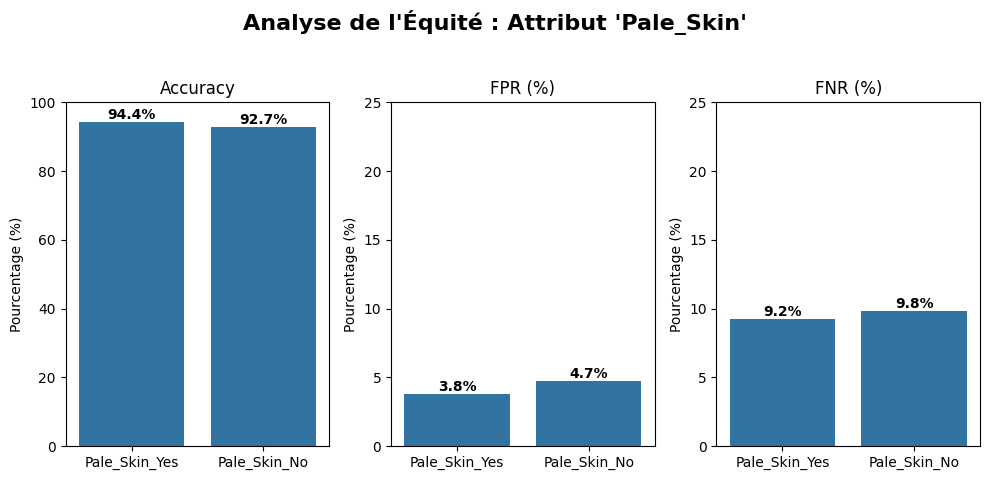

In [37]:
plot_individual_fairness(df_extended)

**Genre (Male)** 
- L'accuracy est plus faible pour les hommes (91.99%) que pour les femmes (93.28%).
- Le FNR (Sourires ratés) atteint 13.54% chez les hommes, contre seulement 8.10% chez les femmes.

Interpretation : Le modèle est "sévère" avec les hommes. Il a presque deux fois plus de chances de rater un sourire masculin. Cela s'explique certainement par le fait que les sourires féminins dans CelebA sont plus démonstratifs (dents visibles, pommettes hautes), et c'est ce qui a du être appris par le modèle.



**Âge (Young)**
- Les personnes plus âgées (Young_No) ont une accuracy plus faible (91.42%) que les plus jeunes (93.22%)
- Le FPR (Faux Sourires) est nettement plus élevé chez les seniors (6.40%) que chez les jeunes (4.11%).

Interpretation : Les rides d'expression  présentes naturellement sur les visages plus âgés sont interprétées à tort par le modèle comme des indices de sourire. Le modèle doit confondre vieillissement et expression de joie.



**Teint de peau (Pale_Skin)**
- C'est sur les personnes à peau claire (Pale_Skin_Yes) que le modèle est le plus performant toutes catégories confondues (94.40%).
- Il y a un écart de 1.7% d'accuracy avec les peaux non-claires. De plus, le FPR et le FNR sont systématiquement plus élevés pour le groupe Pale_Skin_No.

Interpretation : 

Le modèle a été "sur-optimisé" pour les peaux claires, probablement parce qu'elles représentent la grande majorité du dataset CelebA.



**Conclusion**

L'analyse des résultats sur ces différents groupes définis par les citères sensibles identifiés plus tôt démontre que le modèle n'est pas neutre. Il présente un biais d'omission envers les hommes (sourires non détectés), un biais de confusion envers les personnes âgées (rides confondues avec des sourires) et un biais de performance en faveur des peaux claires. Ces résultats illustrent comment les déséquilibres statistiques du dataset CelebA se traduisent par des inégalités de traitement algorithmique.

### 3) Explication post-hoc

Notre analyse post-hoc croise les méthodes LIME et Grad-CAM pour explqiuer le raisonnement du modèle sur quatre cas types (VP, VN, FP, FN). Afin d'étudier les biais d'équité identifiés, les erreurs de prédiction ont été extraites spécifiquement au sein des groupes minoritaires ou discriminés : les Faux Négatifs ont été sélectionnés parmi la population masculine et les Faux Positifs parmi les personnes plus âgées (non-Young), permettant ainsi d'isoler visuellement les caractéristiques morphologiques qui induisent le modèle en erreur.

#### LIME

In [75]:
# On récupère les colonnes d'attributs (Male et Young)
# Note : Dans CelebA, Male=1 signifie Homme, Young=1 signifie Jeune
test_genders = test_df['Male'].values
test_age = test_df['Young'].values

# --- 1. Vrai Positif (VP)
indices_vp = np.where((all_preds == 1) & (all_labels == 1))[0]
idx_vp = indices_vp[0]

# --- 2. Vrai Négatif (VN)
indices_vn = np.where((all_preds == 0) & (all_labels == 0))[0]
idx_vn = indices_vn[0]

# --- 3. Faux Positif (FP) : Prédit Sourire (1) alors que non (0) ET n'est PAS jeune (Young != 1)
# Cela cible les seniors qui sont souvent victimes de ce biais
indices_fp_seniors = np.where((all_preds == 1) & (
    all_labels == 0) & (test_age != 1))[0]
idx_fp = indices_fp_seniors[0] if len(indices_fp_seniors) > 0 else np.where(
    (all_preds == 1) & (all_labels == 0))[0][0]

# --- 4. Faux Négatif (FN) : Prédit Pas Sourire (0) alors que oui (1) ET est un HOMME (Male == 1)
indices_fn_hommes = np.where((all_preds == 0) & (
    all_labels == 1) & (test_genders == 1))[0]
idx_fn = indices_fn_hommes[0] if len(indices_fn_hommes) > 0 else np.where(
    (all_preds == 0) & (all_labels == 1))[0][0]

# Vérification finale
print(f"VP : Index {idx_vp}")
print(f"VN : Index {idx_vn}")
print(f"FP (Senior) : Index {idx_fp} | Young? {test_age[idx_fp]}")
print(f"FN (Homme) : Index {idx_fn} | Male? {test_genders[idx_fn]}")

cas_etudes = {
    "Vrai Positif": idx_vp,
    "Vrai Négatif": idx_vn,
    "Faux Positif": idx_fp,
    "Faux Négatif": idx_fn
}

VP : Index 0
VN : Index 1
FP (Senior) : Index 55 | Young? -1
FN (Homme) : Index 37 | Male? 1


In [76]:
from PIL import Image


def batch_predict(images):
    model.eval()

    # Correction ici : on transforme chaque 'img' (numpy) en PIL Image
    # avant de passer par data_transforms
    batch_list = []
    for img in images:
        # LIME génère des images en float64, on repasse en uint8 pour PIL
        img_pil = Image.fromarray((img).astype('uint8'))
        batch_list.append(data_transforms(img_pil))

    batch = torch.stack(batch_list, dim=0)
    batch = batch.to(device)

    with torch.no_grad():
        logits = model(batch)
        probs = torch.nn.functional.softmax(logits, dim=1)

    return probs.detach().cpu().numpy()

Génération des explications LIME...


100%|██████████| 1000/1000 [00:04<00:00, 214.65it/s]


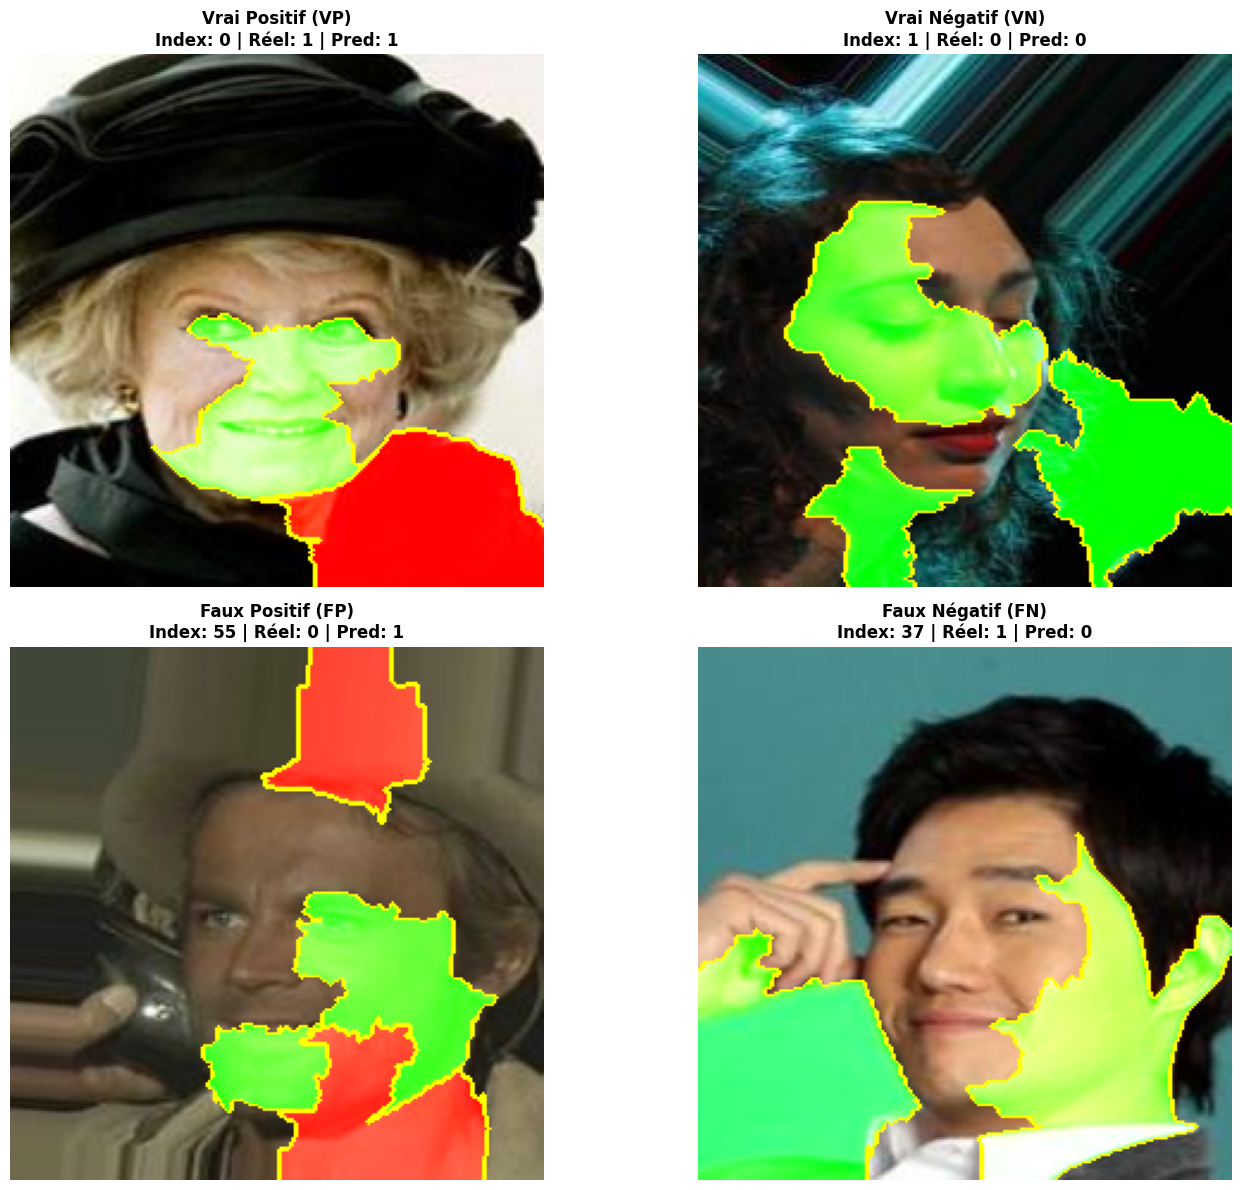

In [77]:
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries
from lime import lime_image
explainer = lime_image.LimeImageExplainer()

# On définit les cas à afficher
cas_list = [
    ("Vrai Positif (VP)", idx_vp), ("Vrai Négatif (VN)", idx_vn),
    ("Faux Positif (FP)", idx_fp), ("Faux Négatif (FN)", idx_fn)
]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

print("Génération des explications LIME...")

for i, (nom, idx) in enumerate(cas_list):
    # 1. Charger et préparer l'image
    path = 'data/CelebA/img_align_celeba/img_align_celeba/' + \
        test_df.iloc[idx]['image_id']
    img_pil = Image.open(path).convert('RGB').resize((224, 224))
    img_array = np.array(img_pil)

    # 2. Obtenir la prédiction et le label réel
    label_reel = all_labels[idx]
    pred_calculee = all_preds[idx]

    # 3. Expliquer l'instance
    # On explique la classe prédite par le modèle
    explanation = explainer.explain_instance(
        img_array, batch_predict, top_labels=2, hide_color=0, num_samples=1000
    )

    # 4. Récupérer l'image et le masque (Vert = Pour, Rouge = Contre)
    temp, mask = explanation.get_image_and_mask(
        pred_calculee, positive_only=False, num_features=5, hide_rest=False
    )

    # 5. Affichage
    axes[i].imshow(mark_boundaries(temp, mask))
    axes[i].set_title(f"{nom}\nIndex: {idx} | Réel: {label_reel} | Pred: {pred_calculee}",
                    fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

**Vrai Positif**

Le modèle regarde quasi exclusivement la zone de la bouche et des dents.

 &rarr; C'est le comportement dans le cas idéal. Le modèle a identifié le trait caractéristique du sourire (étirement des lèvres, visibilité des dents) pour confirmer sa prédiction. La confiance dans la prediction est élevée car l'indice est clair.

**Vrai Négatif**

Les zones d'intérêt sont plus diffuses, mais se concentrent sur une bouche fermée et "neutre".

&rarr; Le modèle valide l'absence de sourire en constatant qu'aucune tension musculaire n'est présente autour des lèvres. Il n'est pas distrait par d'autres éléments du visage.

**Faux Positif**

Le modèle regarde différentes parties du visage, contenant des rides, mais pas la bouche.

&rarr; On voit ici clairement le biais morphologique. La personne ne sourit pas, mais la structure de son visage crée des ombres ou des plis que le modèle interprète à tort comme un sourire. Le modèle confond les signes de l'âge ou la structure osseuse avec une expression de joie.

**Faux Négatif**

Le modèle regarde le menton, le nez ou même le front, mais semble ignorer la bouche qui pourtant esquisse un sourire.

&rarr; C'est le cœur du problème d'équité qu'on avait trouvé chez les hommes. Le modèle ne "trouve" pas les indices habituels (calibrés sur des sourires féminins plus marqués). En cherchant des preuves ailleurs sur le visage, il finit par conclure à tord l'absence de sourire.

**Conclusion**

L'analyse post-hoc via LIME confirme visuellement les biais statistiques identifiés : alors que le modèle se focalise correctement sur la bouche pour les cas de réussite (Vrais Positifs), ses erreurs sur les groupes sous-représentés, notamment les hommes et les personnes âgées, s'expliquent par une attention dérivée vers des caractéristiques morphologiques non pertinentes (rides, structure de la mâchoire ou nez) au détriment des indices réels du sourire. »

#### Grad-Cam

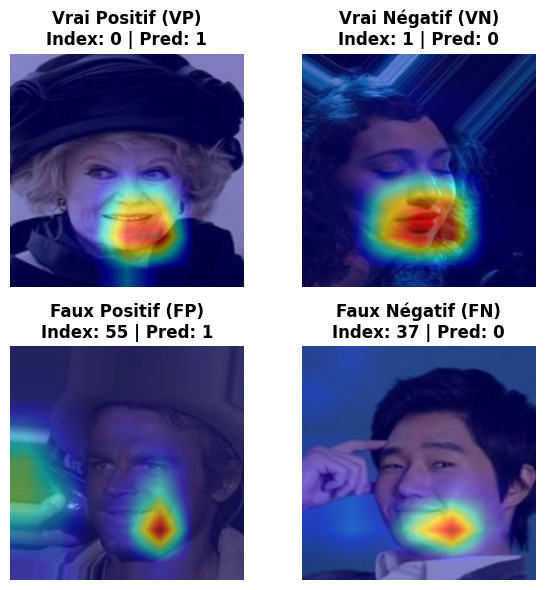

In [78]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# 1. Définition des cibles et de la couche
target_layers = [model.features[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

cas_list = [
    ("Vrai Positif (VP)", idx_vp), ("Vrai Négatif (VN)", idx_vn),
    ("Faux Positif (FP)", idx_fp), ("Faux Négatif (FN)", idx_fn)
]

fig, axes = plt.subplots(2, 2, figsize=(6, 6))
axes = axes.flatten()

for i, (nom, idx) in enumerate(cas_list):
    # Préparation de l'image
    path = 'data/CelebA/img_align_celeba/img_align_celeba/' + test_df.iloc[idx]['image_id']
    img_pil = Image.open(path).convert('RGB').resize((224, 224))
    img_tensor = data_transforms(img_pil).unsqueeze(0).to(device)
    img_float = np.array(img_pil).astype(np.float32) / 255.0

    # On explique la prédiction faite par le modèle
    # (ou on peut forcer ClassifierOutputTarget(1) pour voir où il cherche le sourire)
    targets = [ClassifierOutputTarget(int(all_preds[idx]))]

    # Génération de la heatmap
    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0, :]

    # Superposition
    visualization = show_cam_on_image(img_float, grayscale_cam, use_rgb=True)

    # Affichage
    axes[i].imshow(visualization)
    axes[i].set_title(
        f"{nom}\nIndex: {idx} | Pred: {all_preds[idx]}", fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

**Vrai Positif**

On voit une tache rouge très intense et parfaitement localisée sur la bouche. C'est le comportement attendu d'un bon modèle : il a "allumé" ses neurones de détection du sourire exactement là où se trouve l'information. La prédiction est robuste car basée sur le bon critère.

**Vrai Négatif**

La chaleur est beaucoup plus diffuse ou quasi-inexistante sur les zones expressives. Le modèle ne trouve aucun support pour prédire un sourire, ce qui valide son choix de classer l'image en 0 (Non Souriant).

**Faux Positif**

La zone d'activation ne se situe pas sur la bouche mais sur une autre partie du visage de la personne.

Le réseau a sans doute été trompé par des défauts de la peau, qu'il prend pour un indice de sourire. C'est sans doute ce qui cause le sur-comptage de sourires chez les personnes âgées.

**Faux Négatif**

Ici, on voit que le point chaud est décalé (menton, yeux) ou très faible sur la bouche.

Bien que l'homme sourie, le modèle ne parvient pas à fixer son attention sur ses lèvres. Cela prouve que les caractéristiques apprises pour le sourire sont trop spécifiques aux visages féminins, rendant le modèle ineficace face aux sourires masculins plus subtils.

**Conclusion**

La convergence des analyses LIME et Grad-CAM démontre que les disparités d'équité observées (biais envers les hommes et les seniors) proviennent d'une mauvaise distribution de l'attention spatiale du modèle. Au lieu de se focaliser sur la zone labiale, le réseau se laisse distraire par des attributs morphologiques liés à l'âge ou au genre, ce qui conduit à des erreurs de classification systématiques sur ces populations.